# Downloading airborne magnetics from USGS Project 4962 in the San Luis Valley, Colorado and New Mexico.

Accessed from https://usgs.maps.arcgis.com/apps/webappviewer/index.html?id=df7d8461533540c694177f5e0150deec

Metadata:
https://mrdata.usgs.gov/geophysics/surveys/geophysics2/CO-NM/CO-NM_4296_META.txt

In [1]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
import verde as vd

import airbornegeo

## load data

In [ ]:
fname = pooch.retrieve(
    url="https://mrdata.usgs.gov/geophysics/surveys/geophysics2/CO-NM/CO-NM_4296.zip",
    progressbar=True,
    path=f"{pooch.os_cache('airbornegeo')}",
    processor=pooch.Unzip(members=["CO-NM_4296_contractor.xyz"]),
)[0]
data_df = pd.read_csv(
    fname,
    skiprows=9,
    header=None,
    sep=r"\s+",
    names=[
        "line",
        "dir",  # flight direction
        "lat84",
        "lon84",
        "easting",  # utm WGS-84
        "northing",  # utm WGS-84
        "x27",  # utm NAD-27
        "y27",  # utm NAD-27
        "fid",
        "date",
        "time",
        "radar",  # radar altimeter
        "baro",  # barometric altimeter
        "gps_elev",  # gps elevation
        "diurnal",
        "raw_mag",  # raw mag
        "diu_mag",  # diurnal corrected mag
        "res_mag",  # diurnal + IGRF corrected mag
        "final_mag",  # levelled
    ],
    na_values=-9999,
)

# convert line ID's from strings to unique floats
survey = airbornegeo.Survey(data_df, line_column="line")
survey.unique_line_id()
data_df = survey.data

# make unixtime colum
data_df["date"] = data_df.date.str.replace(".", "/")
data_df["date"] = pd.to_datetime(data_df["date"], format="%Y/%j")
data_df["time"] = pd.to_timedelta(data_df["time"])
data_df["unixtime"] = data_df["date"] + data_df["time"]
data_df = data_df.dropna(subset=["unixtime"])
data_df["unixtime"] = data_df["unixtime"].apply(lambda x: x.timestamp())

# sort by line then time and reset index
data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)

# make column denoting lines vs ties
data_df["line_type"] = np.where(data_df.dir.isin([90, 270]), "line", "tie")

data_df

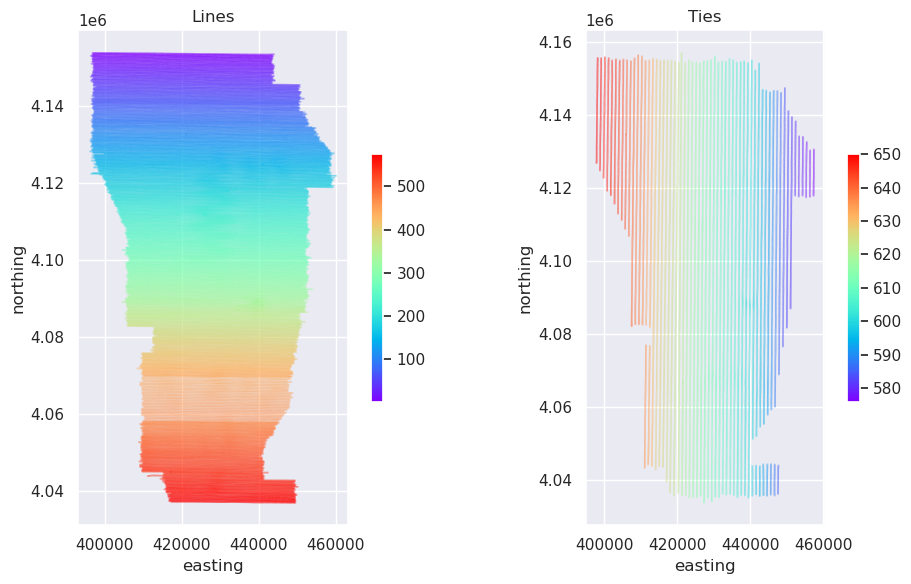

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

df = data_df[::10]
df = df[df.line_type == "line"]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[0],
    colorbar=False,
    title="Lines",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

df = data_df[::10]
df = df[df.line_type == "tie"]
ax = df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[1],
    colorbar=False,
    title="Ties",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

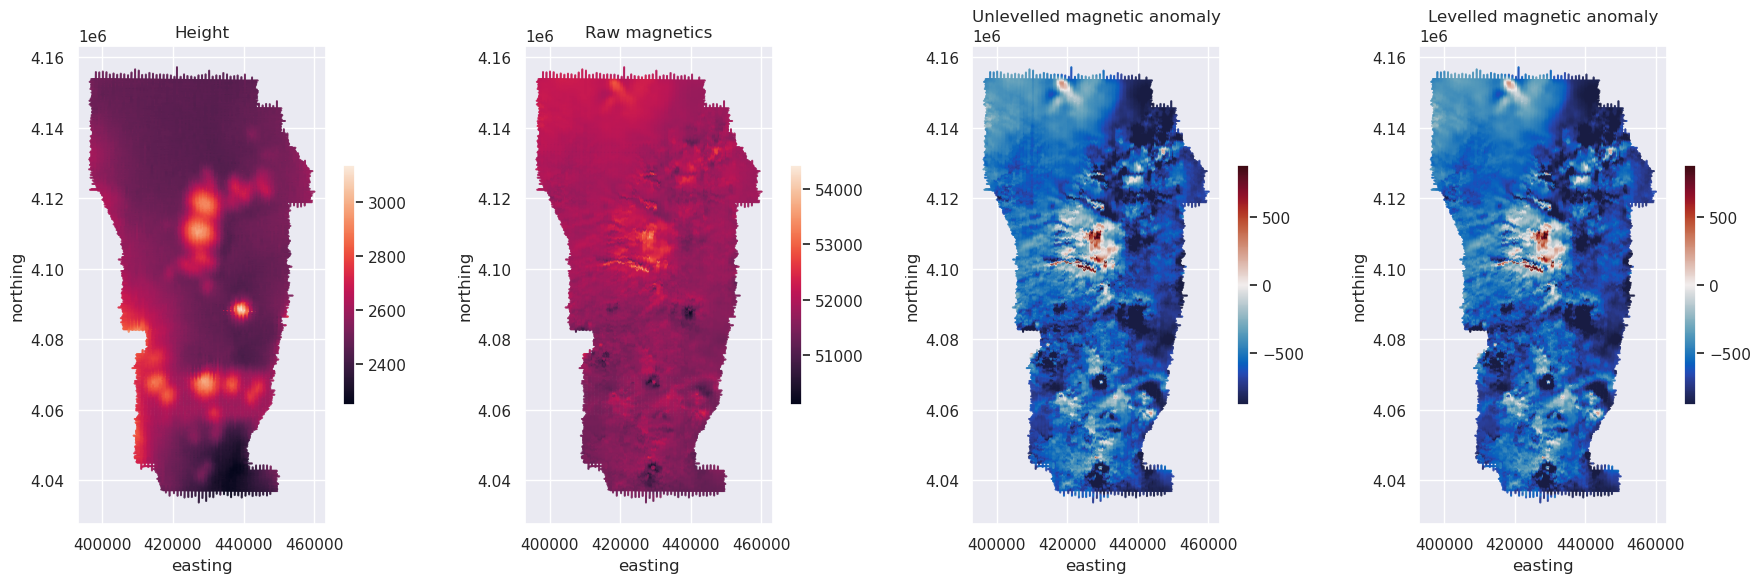

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6))

df = data_df[::10]

ax = df.plot.scatter(
    "easting",
    "northing",
    c="gps_elev",
    s=0.2,
    ax=axs[0],
    colorbar=False,
    title="Height",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="raw_mag",
    s=0.2,
    ax=axs[1],
    colorbar=False,
    title="Raw magnetics",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.res_mag, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="res_mag",
    s=0.2,
    ax=axs[2],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Unlevelled magnetic anomaly",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.final_mag, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="final_mag",
    s=0.2,
    ax=axs[3],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Levelled magnetic anomaly",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

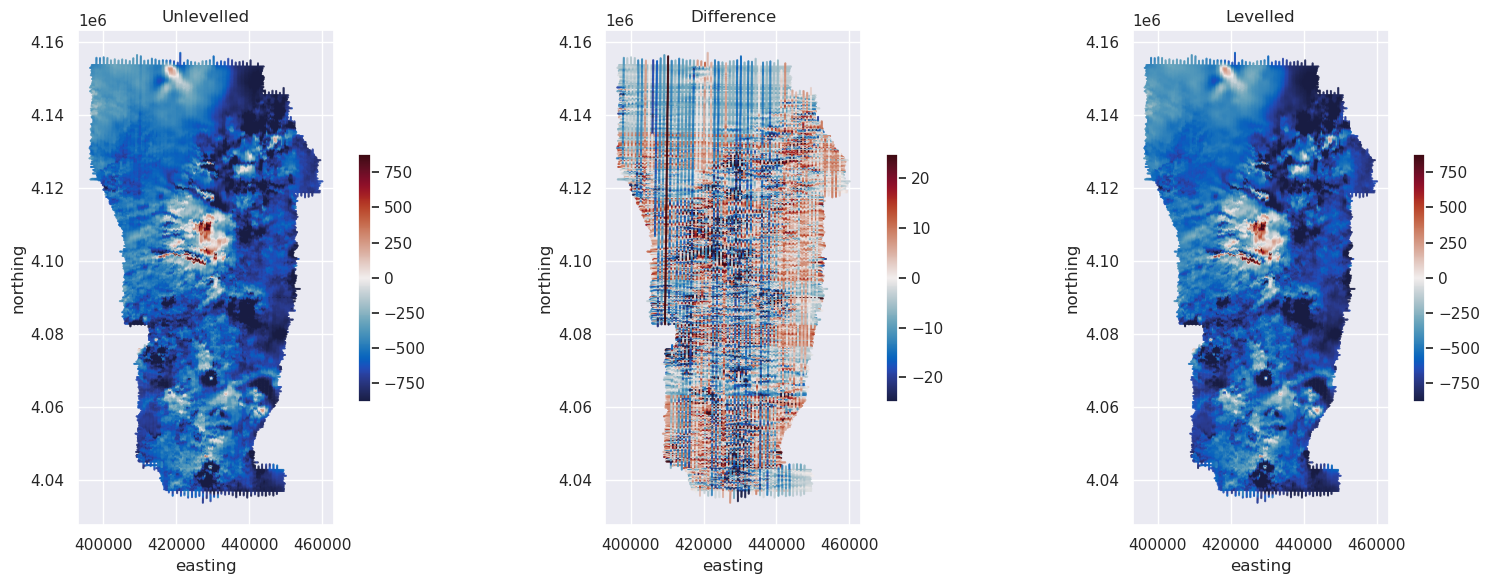

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))


maxabs = vd.maxabs(data_df.res_mag, data_df.final_mag, percentile=95)
data_df["dif"] = data_df.final_mag - data_df.res_mag
dif_maxabs = vd.maxabs(data_df.dif, percentile=95)
df = data_df[::10]

ax = df.plot.scatter(
    "easting",
    "northing",
    c="res_mag",
    s=0.2,
    ax=axs[0],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    s=0.2,
    ax=axs[1],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-dif_maxabs,
    vmax=dif_maxabs,
    title="Difference",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="final_mag",
    s=0.2,
    ax=axs[2],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Levelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [6]:
data_df.columns

Index(['line', 'dir', 'lat84', 'lon84', 'easting', 'northing', 'x27', 'y27',
       'fid', 'date', 'time', 'radar', 'baro', 'gps_elev', 'diurnal',
       'raw_mag', 'diu_mag', 'res_mag', 'final_mag', 'unixtime', 'line_type',
       'dif'],
      dtype='str')

In [8]:
# save to csv
data_df[
    [
        "line",
        "line_type",
        "lat84",
        "lon84",
        "easting",
        "northing",
        "unixtime",
        "gps_elev",
        "res_mag",
        "final_mag",
    ]
].rename(
    columns={
        "gps_elev": "height",
        "res_mag": "unlevelled_tfa",
        "final_mag": "levelled_tfa",
    }
).to_csv("../data/san_luis_magnetics.csv", index=False)